In [ ]:
# Task 3: Data Cleaning

## Oasis Infobyte Data Analytics Internship

### Objective
The objective of this project is to clean and transform a messy dataset
into a reliable, analysis-ready dataset.

### Dataset
Titanic Dataset

### Tools Used
- Python
- Pandas
- NumPy
- Jupyter Notebook

In [9]:
# Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [33]:
# Load Dataset
df = pd.read_csv("../data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
# shape
df.shape

(891, 12)

In [39]:
# columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [41]:
# First 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
# Last 5 rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [45]:
# Data Type
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [51]:
## Data Quality Report
# Null Count
null_report = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

null_report

,Null_Count,Null_Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [55]:
# Duplicate Check
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [61]:
# Numeric Column
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

df[numeric_columns].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [67]:
# Handling Missing Value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [69]:
# Calculate the number and percentage of missing values in each column

missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

# Display only columns containing missing values
missing_report[missing_report["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [71]:
# Fill missing Age values with the median age

df["Age"] = df["Age"].fillna(df["Age"].median())

# Verify that no missing values remain in the Age column
df["Age"].isnull().sum()

0

In [73]:
# Fill missing Embarked values with the most frequently occurring value

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Verify the result
df["Embarked"].isnull().sum()

0

In [75]:
# Replace missing Cabin values with "Unknown"

df["Cabin"] = df["Cabin"].fillna("Unknown")

# Verify the result
df["Cabin"].isnull().sum()

0

In [77]:
# Check missing values after cleaning

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [85]:
## Data Standardisation
# Identify categorical columns in the dataset

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

categorical_columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [81]:
# Display unique values for each categorical column

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


Name:
['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima']

Sex:
['male' 'female']

Ticket:
['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450' '330877'
 '17463' '349909' '347742' '237736' 'PP 9549' '113783' 'A/5. 2151'
 '347082' '350406' '248706' '382652' '244373' '345763' '2649']

Cabin:
['Unknown' 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C

In [83]:
# Check unique values in the Sex column

df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [87]:
# Check unique values in the Embarked column

df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [89]:
# Remove leading and trailing whitespace from text columns

for column in categorical_columns:
    df[column] = df[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

In [91]:
# Verify that the categorical columns are consistently formatted

for column in categorical_columns:
    print(f"{column}: {df[column].isnull().sum()} missing values")

Name: 0 missing values
Sex: 0 missing values
Ticket: 0 missing values
Cabin: 0 missing values
Embarked: 0 missing values


In [93]:
## Data Type Correction
# Display the current data types of all columns

df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [101]:
# Convert PassengerId from integer to string because it is an identifier

df["PassengerId"] = df["PassengerId"].astype("string")

# Convert categorical columns to the category data type

df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

In [99]:
# Verify that numerical columns have appropriate data types

numeric_columns = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

df[numeric_columns].dtypes

Survived      int64
Pclass        int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
dtype: object

In [103]:
# Display the final data types after correction

df.dtypes

PassengerId    string[python]
Survived                int64
Pclass                  int64
Name                   object
Sex                  category
Age                   float64
SibSp                   int64
Parch                   int64
Ticket                 object
Fare                  float64
Cabin                  object
Embarked             category
dtype: object

In [105]:
## Outlier Detection
# Select numerical columns for outlier detection

numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [107]:
# Define a function to detect outliers using the IQR method

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [115]:
# Select meaningful numerical variables for outlier detection

outlier_columns = ["Age", "Fare", "SibSp", "Parch"]

outlier_summary = []

for column in outlier_columns:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df, column)

    outlier_summary.append({
        "Column": column,
        "Outlier_Count": len(outliers),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Outlier_Count,Lower_Bound,Upper_Bound
0,Age,66,2.50,54.50
1,Fare,116,-26.72,65.63
2,SibSp,46,-1.50,2.50
3,Parch,213,0.00,0.00


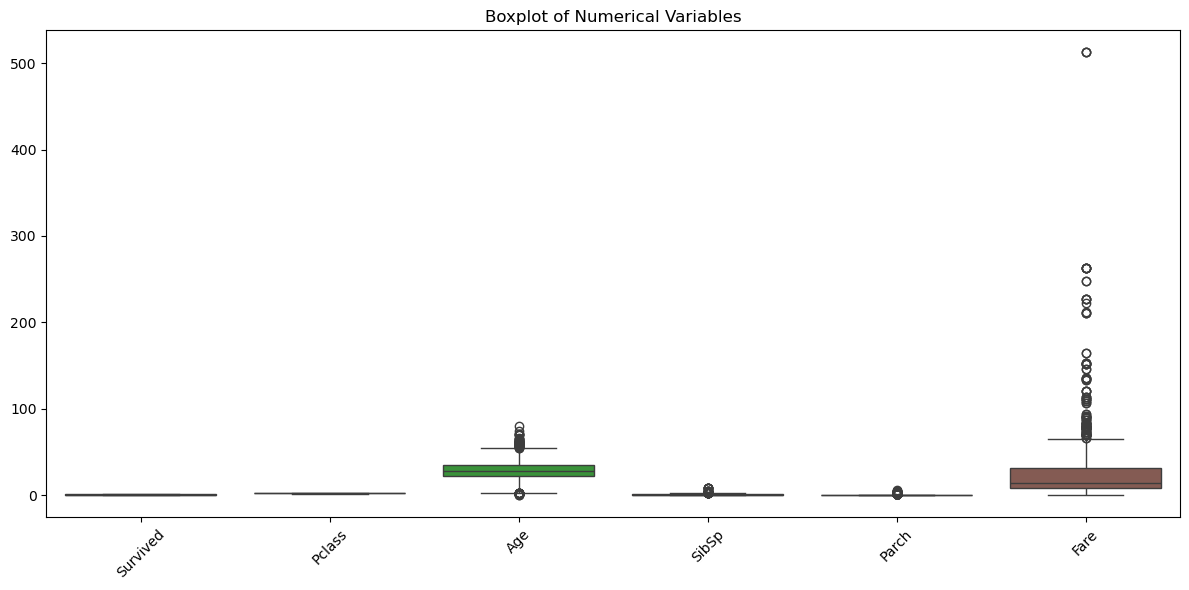

In [117]:
# Create boxplots to visually inspect potential outliers

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numeric_columns])

plt.title("Boxplot of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [119]:
## Before vs After Cleaning Summary
# Load the original dataset again to compare the before and after states

original_df = pd.read_csv("../data/train.csv")

print("Original dataset loaded successfully.")

Original dataset loaded successfully.


In [123]:
# Before cleaning metrics
# Calculate data quality metrics before cleaning

before_rows = len(original_df)
before_nulls = original_df.isnull().sum().sum()
before_duplicates = original_df.duplicated().sum()

print("Rows before cleaning:", before_rows)
print("Missing values before cleaning:", before_nulls)
print("Duplicate rows before cleaning:", before_duplicates)

Rows before cleaning: 891
Missing values before cleaning: 866
Duplicate rows before cleaning: 0


In [125]:
# After cleaning metrics
# Calculate data quality metrics after cleaning

after_rows = len(df)
after_nulls = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

print("Rows after cleaning:", after_rows)
print("Missing values after cleaning:", after_nulls)
print("Duplicate rows after cleaning:", after_duplicates)

Rows after cleaning: 891
Missing values after cleaning: 0
Duplicate rows after cleaning: 0


In [127]:
# Create a before-and-after comparison table

comparison = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        before_rows,
        before_nulls,
        before_duplicates
    ],
    "After Cleaning": [
        after_rows,
        after_nulls,
        after_duplicates
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Row Count,891,891
1,Total Missing Values,866,0
2,Duplicate Rows,0,0


In [129]:
# Compare data types before and after cleaning

dtype_comparison = pd.DataFrame({
    "Column": original_df.columns,
    "Before_Dtype": original_df.dtypes.astype(str).values,
    "After_Dtype": df.dtypes.astype(str).values
})

dtype_comparison

,Column,Before_Dtype,After_Dtype
0,PassengerId,int64,string
1,Survived,int64,int64
2,Pclass,int64,int64
3,Name,object,object
4,Sex,object,category
5,Age,float64,float64
6,SibSp,int64,int64
7,Parch,int64,int64
8,Ticket,object,object
9,Fare,float64,float64


In [131]:
## Final validation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    string  
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        891 non-null    object  
 11  Embarked     891 non-null    category
dtypes: category(2), float64(2), int64(4), object(3), string(1)
memory usage: 71.7+ KB


In [133]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [135]:
df.duplicated().sum()

0

In [137]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [139]:
df.to_csv("../output/cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
